<a href="https://colab.research.google.com/github/penajuanmanuel6-hub/automated-etl-pipeline/blob/main/pipeline_etl_logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        zona  volumen_hl
0  Antioquia      3650.0
1    Central      3825.0
2      Costa      9000.0


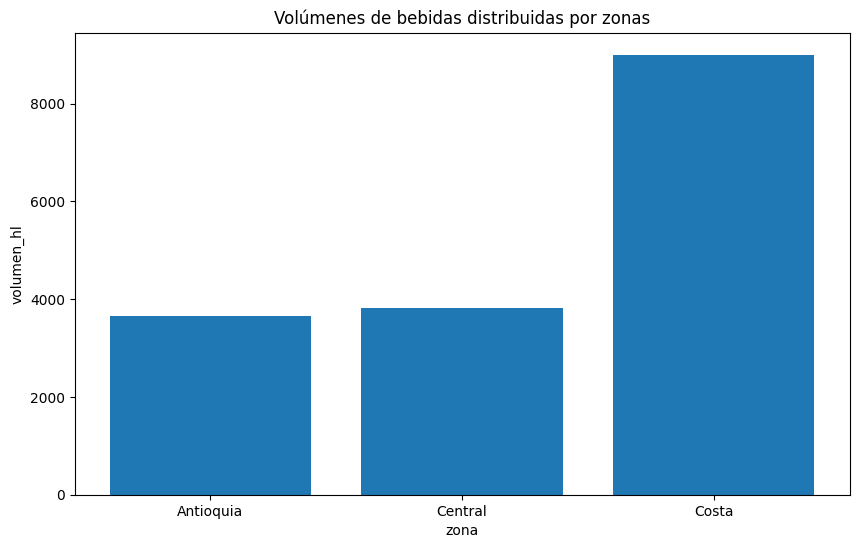

In [18]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


# Datos iniciales (Logística de transporte, ejemplo: bebidas)
despachos = pd.DataFrame({
    "id_pedido": [501, 502, 503, 504, 505, 506, 507, 508],
    "zona": ["Central", "Central", "Costa", "Costa", "Costa", "Antioquia", "Antioquia", "Central"],
    "ruta": ["Bogotá-Chía", "Bogotá-Chía", "Barranquilla-Cartagena", "Barranquilla-Cartagena",
             "Barranquilla-Cartagena", "Medellín-Rionegro", "Medellín-Rionegro", "Bogotá-Soacha"],
    "volumen_hl": [1200.0, None, 3100.0, 2900.0, None, 1800.0, 1850.0, 1350.0]
})

# 1. Conexión y Configuración (Raíz)
def connect():
    engine = sqlite3.connect(":memory:")
    return engine

# 2. Extracción de Datos con SQL (Rama)
def extraer_datos(query, conexion):
    df_resultado = pd.read_sql(query, conexion)
    return df_resultado

# 3. Limpieza y Transformación de Datos (Ramas)
def limpiar_datos(df):
    df = df.drop_duplicates()
    df["volumen_hl"] = df.groupby("zona")["volumen_hl"].transform(lambda x: x.fillna(x.median()))
    return df

# 4. Generación del Reporte (Hojas y Frutos)
def generar_reporte(df):
    resumen = df.groupby("zona")["volumen_hl"].sum().reset_index()
    print(resumen)
    return resumen

# 5. Orquestación (Tronco)
if __name__ == "__main__":
    conexion = connect()
    despachos.to_sql('despachos', conexion, if_exists='replace', index=False)

    sql = "SELECT * FROM despachos;"
    df_extraido = extraer_datos(sql, conexion)
    df_limpio = limpiar_datos(df_extraido)
    resumen = generar_reporte(df_limpio)

plt.figure(figsize=(10,6))
plt.bar(resumen["zona"], resumen["volumen_hl"])
plt.xlabel("zona")
plt.ylabel("volumen_hl")
plt.title("Volúmenes de bebidas distribuidas por zonas")
plt.show()